In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using scikit-learn.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

In [4]:
np.random.seed(42)
X_data = np.random.randn(200, 2)
# 0 = Legit transaction, 1 = Fraudulent transaction
y_data = np.array([0]*190 + [1]*10)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

In [6]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
y_probs = model.predict_proba(X_test)[:, 1]

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 2. Plot the ROC curve for your classifier using sklearn.metrics.roc_curve and matplotlib, and display the AUC score on the plot.


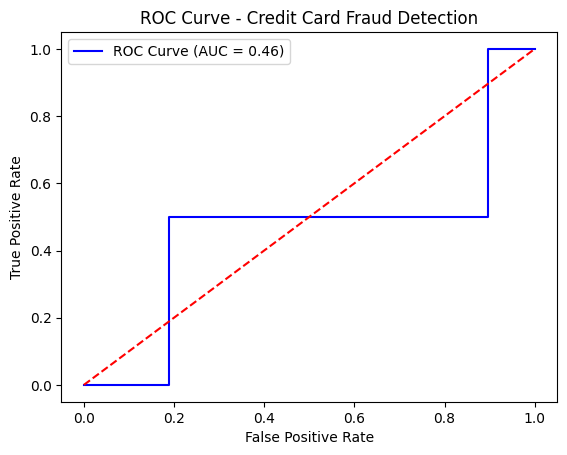

In [10]:
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {round(roc_auc, 2)})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guess line
plt.title('ROC Curve - Credit Card Fraud Detection')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 3. Plot the Precision-Recall curve for your model using sklearn.metrics.precision_recall_curve and matplotlib, and explain in one line why this curve is useful for imbalanced datasets.<br><br><em><strong>Hint:</strong> Focus on how precision and recall behave when the positive class is rare.</em>

In [14]:
from sklearn.metrics import precision_recall_curve

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)

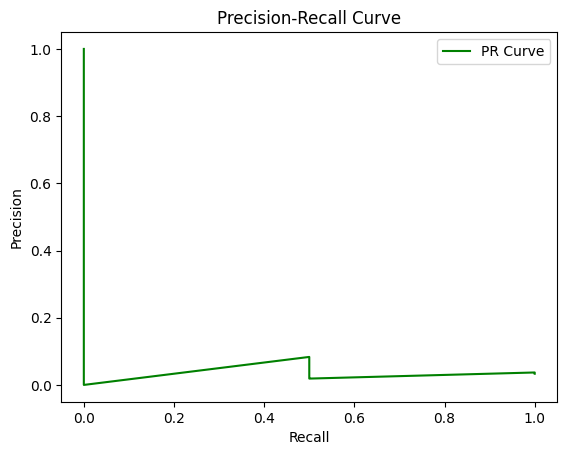

In [16]:
plt.figure()
plt.plot(recall, precision, color='green', label='PR Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

This curve is useful because it ignores True Negatives and focuses entirely on the rare positive class, showing how well the model catches fraud without generating a massive wave of false alarms.

# 4. Calculate the log loss (cross-entropy loss) for your test set predictions using sklearn.metrics.log_loss and print the result.

In [18]:
from sklearn.metrics import log_loss

test_log_loss = log_loss(y_test, y_probs)

In [19]:
print("Test Set Log Loss:", round(test_log_loss, 4))

Test Set Log Loss: 0.1744


# 5. Change the class distribution in your test set to be even more imbalanced (e.g., only 2% positive class), re-calculate accuracy, AUC, and log loss, and write 2 lines explaining which metric is most misleading and why.<br><br><em><strong>Hint:</strong> Accuracy can be high even if the model ignores the minority class.</em>

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [20]:
np.random.seed(42)
X_extreme = np.random.randn(100, 2)
y_extreme = np.array([0]*98 + [1]*2)

In [22]:
extreme_preds = model.predict(X_extreme)
extreme_probs = model.predict_proba(X_extreme)[:, 1]

In [23]:
acc = accuracy_score(y_extreme, extreme_preds)
auc_score = roc_auc_score(y_extreme, extreme_probs)
loss = log_loss(y_extreme, extreme_probs)

In [24]:
print("Accuracy :", round(acc, 4))
print("AUC Score:", round(auc_score, 4))
print("Log Loss :", round(loss, 4))

Accuracy : 0.98
AUC Score: 0.4643
Log Loss : 0.128


Accuracy is the most misleading metric here because a baseline model that lazily guesses "legit" for every single transaction will automatically score an amazing $98\%$ accuracy. It completely hides the fact that the system is failing to catch a single actual fraud instance.